In [110]:
# Import the required libraries
import numpy as np
from pathlib import Path
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [111]:
FILE_PATH = Path.cwd().parent / "datasets" / "L1.csv" # Generalized for any machine

In [112]:
df=pd.read_csv(FILE_PATH)

In [113]:
df.head() # Used to Inspect the first five elements from the top
# Alternatively we can also use the .tail() method to get the bottommost 5 elements.
# The method also accepts a parameter of int n : suppose if df.head(n) then will return the first n elements .

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


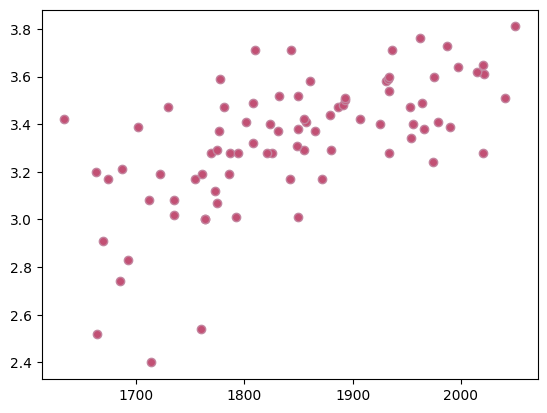

In [114]:
plt.scatter(df['SAT'],df['GPA'],color="#C25074",edgecolors="#C3859F")
plt.show()

In [115]:
df.info() 
# The info method is used to get the insights of the column's : dtype ,
# the number of values which are not null (Nn-Null Count) and the no of rows in dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SAT     84 non-null     int64  
 1   GPA     84 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.4 KB


In [116]:
df.describe()
# The describe function is a important method used to describe some important stastical values like :
#  count : Basically the number of row entries
#  mean : the average of the values in that column , gives us an overall idea of the central tendency
#  std  : the standard deviation which is the square-root of variance of the dataset , 
#       what it gives ? - The spread of the data in the units same as data .env
# The other values return in the percentage is the quartile value of the data respectively.

,SAT,GPA
count,84.000000,84.000000
mean,1845.273810,3.330238
std,104.530661,0.271617
min,1634.000000,2.400000
25%,1772.000000,3.190000
50%,1846.000000,3.380000
75%,1934.000000,3.502500
max,2050.000000,3.810000


In [117]:
df.corr() 
# Another imortant methods (especially for regression like problems) where we use the correlation formula to find 
# relation between the n columns and returns a n x n matrix of correltion.
# Why we need this ? - This explains how different columns are correlated to each other and if correlate what type of correlation :
# Positive , Negative ; Strong - Weak.

,SAT,GPA
SAT,1.000000,0.637184
GPA,0.637184,1.000000


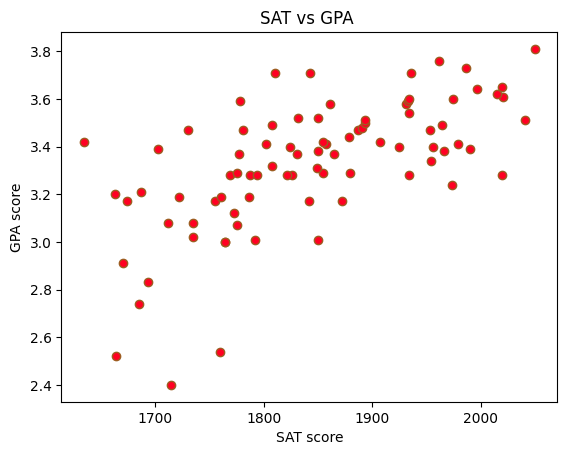

In [118]:
# A simple scatter plot demonstrating the relationship between SAT and GPA . 
# A scatte plot helps us to check whether there exists a linear relationship between the two axis plotted . 
# In our case there seems a slight positive correlation in between .
plt.scatter(    
                marker = 'o',
                color = "#FF0022",
                x=df.SAT,
                y=df.GPA,
                edgecolors = "#9D5D21"
            )
plt.xlabel('SAT score')
plt.ylabel('GPA score')
plt.title('SAT vs GPA ')
plt.show()

In [119]:
df[df['GPA']<2.6] # These are the culprit behind all problems

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54


In [120]:
# # Fix
# df = df[df['GPA']>2.8]

In [121]:
# Split the dataset into two portions :
#                                           [[The predictors]] ----- [The prediction ]
X=df[['SAT']] # Always must be 2D
y=df['GPA']

In [122]:
# Import the LinearRegression module to implement LinearRegression
from sklearn.linear_model import LinearRegression

# The train_test_split is function which helps us to split the dataset into training set and testing set.
from sklearn.model_selection import train_test_split

In [123]:
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2 , random_state=25 )
# Why do this ? --- Cause we want our model to evaluate on unseen data and then evaluate whether the model is useful or not .

In [124]:
# Instantiate the model and fit the model with the training parameters
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [125]:
# Take a look at the slope and the intercept of the equation calculated by the model
print("Slope (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

Slope (m): 0.0015144023628957473
Intercept (b): 0.5328876544078698


In [126]:
# Make predictions on the testing set 
y_pred = model.predict(X_test)

In [127]:
# Calculate the residuals 
residuals = y_test - y_pred

In [128]:
# For evaluation of the model we will use the R2 score . 
# Importing r2_score from the metrics module
from sklearn.metrics import r2_score

In [129]:
# Print the R2 score to take a look at the predicted outcome.
print("The R^2 value of the model is :", r2_score(y_test,y_pred))
# A quiet weak prediction.

The R^2 value of the model is : 0.4734280838653345


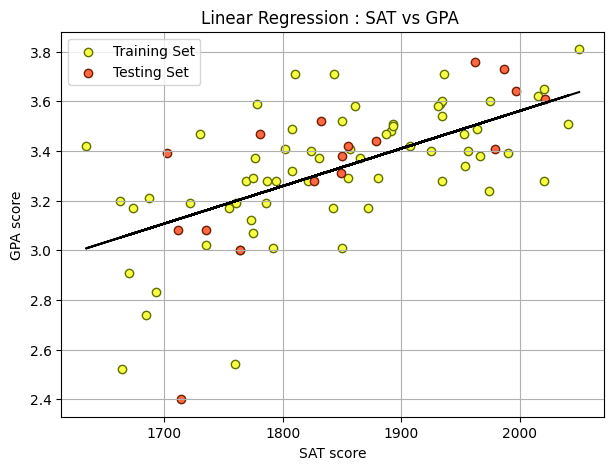

In [130]:
# Now lets try fitting a line using the model's prediction on X.
plt.figure(figsize=(7,5))
plt.grid(visible=True,axis='both')
plt.scatter(X_train,y_train,color="#F9FF42",edgecolor="#626F00",label='Training Set')
plt.scatter(X_test,y_test,color="#FF6842",edgecolor="#6F1E00",label='Testing Set')
plt.plot(X,model.predict(X),color='#000000')
plt.xlabel('SAT score')
plt.ylabel('GPA score')
plt.title('Linear Regression : SAT vs GPA ')
plt.legend()
plt.show()

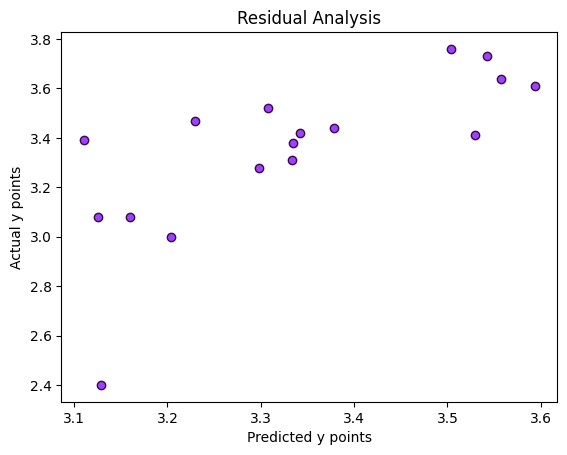

In [131]:
# Residual Analysis - Peeking at the residuals to look whether there is a linear pattern or not
plt.scatter(y_pred,y_test,color="#9D42FF",edgecolor="#3B064A")
plt.xlabel('Predicted y points')
plt.ylabel('Actual y points')
plt.title('Residual Analysis')
plt.show()

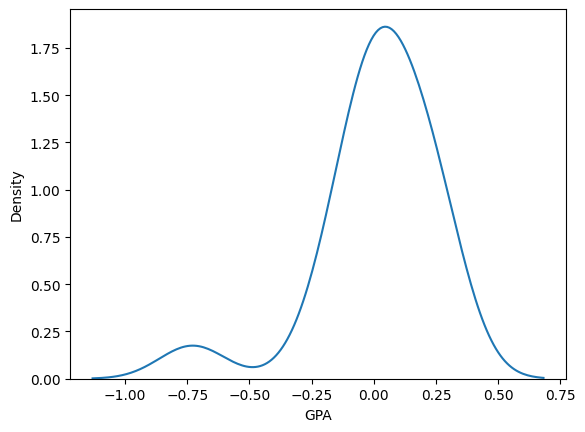

In [132]:
sns.kdeplot(residuals)
plt.show()
# WE can clearly see that our kdeplot is skewed and this is valid considering the outliers .
# This means we should have taken some measures to before hand to deal with it .

In [133]:
# First, train your model and get predictions
import statsmodels.api as sm

X = sm.add_constant(X) # Statsmodels requires adding a constant for the intercept
model = sm.OLS(y, X).fit()
residuals = model.resid
fitted_values = model.fittedvalues

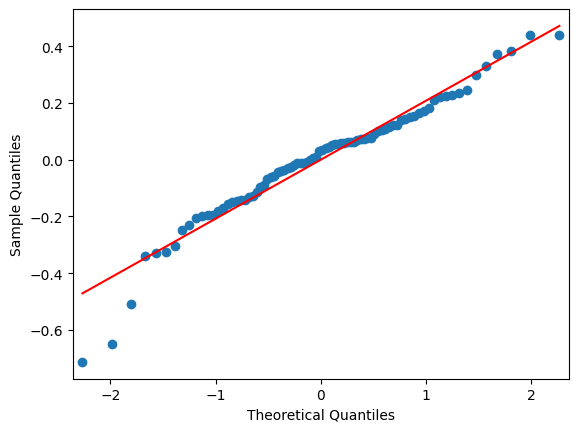

In [134]:
from scipy import stats
# 1. Statistical Test (Shapiro-Wilk) - p-value > 0.05 means normally distributed
shapiro_test = stats.shapiro(residuals)

# 2. Visual Check (Q-Q Plot) - Points should follow the straight red line
sm.qqplot(residuals, line='s')
plt.show()


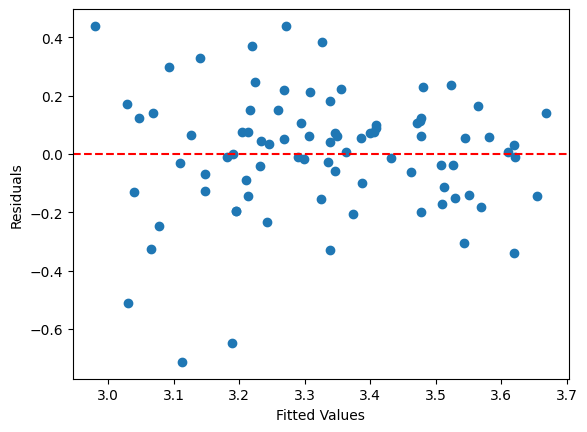

In [135]:
from statsmodels.stats.diagnostic import het_breuschpagan

# 1. Statistical Test - p-value > 0.05 means homoscedastic (good)
bp_test = het_breuschpagan(residuals, model.model.exog)

# 2. Visual Check - Should look like a random cloud, no funnel shape
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

In [136]:
from statsmodels.stats.stattools import durbin_watson

dw_value = durbin_watson(residuals) # Target value is ~2.0
dw_value

np.float64(0.949651821744357)

In [137]:
# This confirms that we have two groups of students one which is following the line and the other down-left group is the one responsiblen for this , we can either : 
""" 
1. Remove this value and refit
2. Create a binary group for people below and above some criteria so model learns about this pattern too.
"""

' \n1. Remove this value and refit\n2. Create a binary group for people below and above some criteria so model learns about this pattern too.\n'

In [138]:
# Improvements 

In [139]:
# A curvilienear model is to predict better in this dataset given the scatter plot

In [140]:
# Now beyond this we will try to fit a Polynomial Curve to this model and try to look whether that model explaince variance the best or not
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3 # The degree of the equation 
                          ,include_bias=True
                          ) # Instanitation

X_train_poly = poly.fit_transform(X_train)
 # We use fit transform once on X_train so it learns ON X_train data and there is no data leaks to X_test.
X_test_poly = poly.transform(X_test)

In [141]:
poly_lr = LinearRegression() # The model instantiation remains same but the features are polynomial in degree now
poly_lr.fit(X_train_poly,y_train)
y_pred_poly = poly_lr.predict(X_test_poly)

In [142]:
print(f'r2_score for polynomial_lr model ; {r2_score(y_test,y_pred_poly)}')

r2_score for polynomial_lr model ; 0.48869115747247693


c:\Users\hp\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


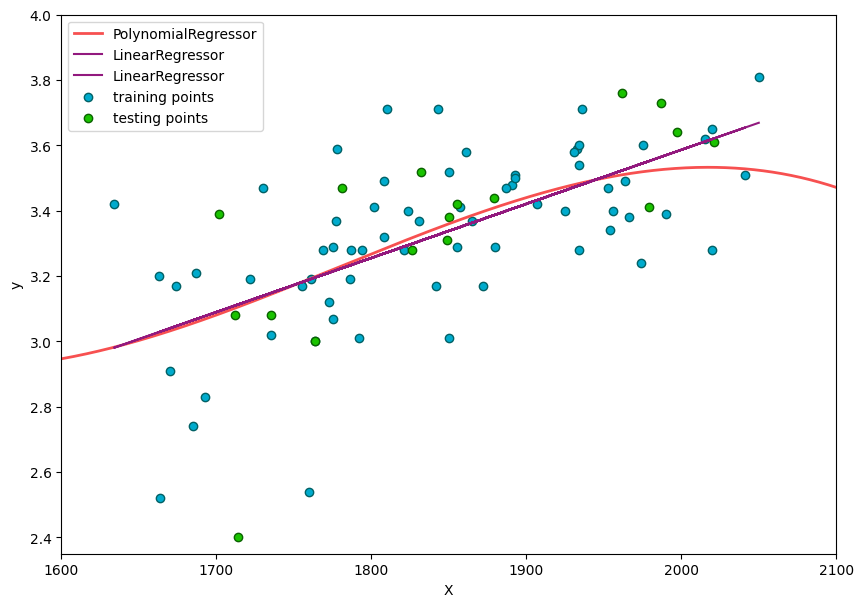

In [143]:
# Plotting requires us to make a linear line and then transforming it using our feature transformer and then prediction using model
X_new=np.linspace(1600,2100, 500).reshape(500, 1) # We took this by considering the boundaries of the graph in y axis for visualization.
X_new_poly = poly.transform(X_new)
y_new = poly_lr.predict(X_new_poly)

# Now lets visualize the graph
plt.figure(figsize=(10,7))
plt.plot(X_new,y_new,color="#F75050",linewidth=2,label='PolynomialRegressor')
plt.plot(X,model.predict(X),color="#92197E",label='LinearRegressor')
plt.scatter(X_train,y_train,label='training points',color="#00ABCD",edgecolor="#026165") 
plt.scatter(X_test,y_test,label='testing points',color="#1AC300",edgecolor="#0A6200") 
plt.xlabel('X')
plt.ylabel('y')
plt.xlim([1600,2100])
plt.ylim([2.35,4])
plt.legend()
plt.show()

In [144]:
# We can clearly see that this model fits a bit better than our linear model.
# Because the scatterplot was bit curvilinear to begin with